# Time-Varying Sector Betas Around Market Stress Events

Executable notebook for the repository. It (1) reproduces the published 52-week rolling-beta results in `outputs/crisis_beta_summary.csv` from the processed data, and (2) adds two checks that the original analysis did not include:

- **Window-overlap diagnostic.** A 52-week rolling beta averaged over a 5-week event (the COVID crash) is dominated by pre-event data. We measure how much of each rolling window actually falls inside the event.
- **Event-window betas and formal tests.** We estimate beta directly from daily data *inside* each event window, and test for a beta shift with an interaction regression, r_s = a + b r_m + sum_e (c_e D_e + d_e D_e r_m) + e, using HAC (Newey-West) standard errors. d_e is the change in beta during event e.

Data: `data/processed/returns_clean.csv` (daily) and `returns_clean_weekly.csv` (weekly); excess returns over the 3-month T-bill (DTB3).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

SECTORS = ["XLK", "XLE", "XLF", "XLV", "XLP", "XLU", "XLY"]
daily = pd.read_csv("../data/processed/returns_clean.csv", parse_dates=["date"], index_col="date")
weekly = pd.read_csv("../data/processed/returns_clean_weekly.csv", parse_dates=["date"], index_col="date")
events = pd.read_csv("../data/raw/events.csv", encoding="utf-8-sig", parse_dates=["start_date", "end_date"])
EVENT_LABELS = {"COVID_crash": "COVID Crash", "COVID_recovery": "COVID Recovery", "Bear_2022": "2022 Bear Market",
                "Rate_hike": "Rate Hike", "Bank_crisis": "SVB Crisis", "AI_rally": "AI Rally"}
events["label"] = events["event_name"].map(EVENT_LABELS)
print(f"Daily: {daily.index.min().date()} -> {daily.index.max().date()} ({len(daily)} rows); weekly: {len(weekly)} rows")
events

Daily: 2018-01-02 -> 2024-12-30 (1760 rows); weekly: 366 rows


,event_name,start_date,end_date,event_type,label
0,COVID_crash,2020-02-19,2020-03-23,crisis,COVID Crash
1,COVID_recovery,2020-03-24,2020-12-31,recovery,COVID Recovery
2,Bear_2022,2022-01-03,2022-10-12,crisis,2022 Bear Market
3,Rate_hike,2022-03-16,2023-07-26,macro,Rate Hike
4,Bank_crisis,2023-03-08,2023-05-01,crisis,SVB Crisis
5,AI_rally,2023-10-01,2024-12-31,expansion,AI Rally


## 1. Rolling betas (52-week primary, 26-week robustness) and reproduction check

In [2]:
def rolling_beta(df, window):
    m = df["excess_SPY"]
    return pd.DataFrame({s: df[f"excess_{s}"].rolling(window).cov(m) / m.rolling(window).var() for s in SECTORS})

beta52, beta26 = rolling_beta(weekly, 52), rolling_beta(weekly, 26)

REPORTED = ["COVID Crash", "Rate Hike", "SVB Crisis", "AI Rally"]
ev = events.set_index("label")
crisis52 = pd.DataFrame({e: beta52.loc[ev.loc[e, "start_date"]:ev.loc[e, "end_date"]].mean() for e in REPORTED}).T
crisis26 = pd.DataFrame({e: beta26.loc[ev.loc[e, "start_date"]:ev.loc[e, "end_date"]].mean() for e in REPORTED}).T

published = pd.read_csv("../outputs/crisis_beta_summary.csv").pivot(index="event", columns="sector", values="mean_beta")
max_diff = (crisis52 - published.loc[crisis52.index, crisis52.columns]).abs().max().max()
print(f"Max abs difference vs published crisis_beta_summary.csv: {max_diff:.2e}")
assert max_diff < 1e-6, "reproduction failed"
crisis52.round(3)

Max abs difference vs published crisis_beta_summary.csv: 8.88e-16


,XLK,XLE,XLF,XLV,XLP,XLU,XLY
COVID Crash,1.093,1.404,1.145,0.905,0.739,0.726,0.989
Rate Hike,1.239,0.681,0.979,0.683,0.612,0.619,1.308
SVB Crisis,1.213,0.843,1.007,0.637,0.638,0.737,1.290
AI Rally,1.400,0.501,0.888,0.552,0.391,0.390,1.262


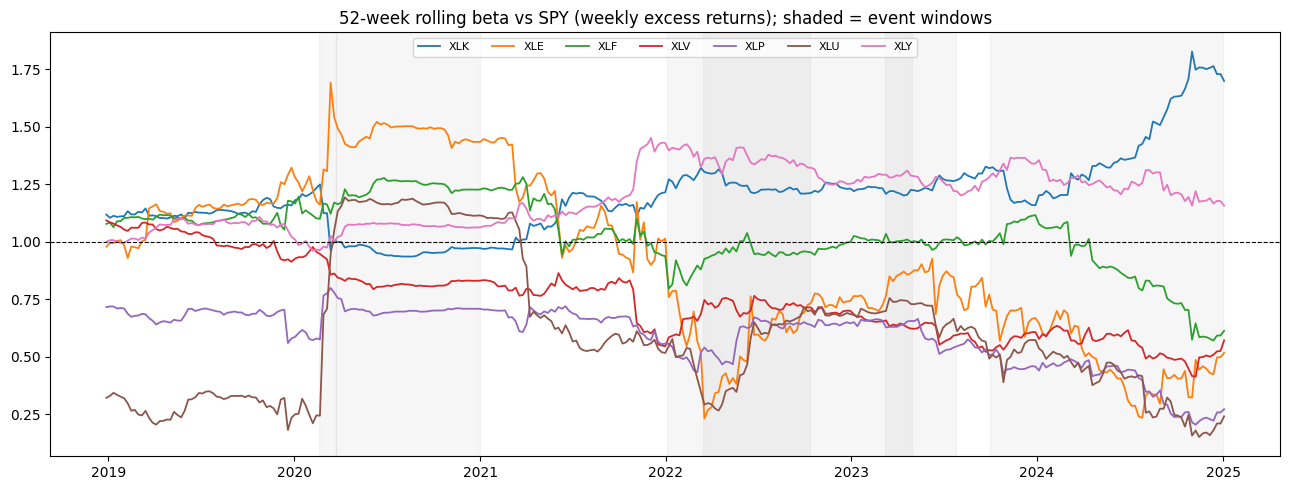

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
for s in SECTORS:
    ax.plot(beta52.index, beta52[s], label=s, lw=1.3)
for _, r in events.iterrows():
    ax.axvspan(r.start_date, r.end_date, alpha=0.07, color="grey")
ax.axhline(1, color="black", lw=0.8, ls="--")
ax.set_title("52-week rolling beta vs SPY (weekly excess returns); shaded = event windows")
ax.legend(ncol=7, loc="upper center", fontsize=8); plt.tight_layout(); plt.show()

## 2. Window-overlap diagnostic

For each event, what share of the observations inside the 52-week (or 26-week) rolling windows used during that event actually fall inside the event? If the share is small, the "event beta" mostly reflects the months *before* the event.

In [4]:
rows = []
for _, r in events.iterrows():
    in_event = weekly.loc[r.start_date:r.end_date].index
    for win in (52, 26):
        shares = []
        for d in in_event:
            pos = weekly.index.get_loc(d)
            if pos + 1 < win:
                continue
            w_idx = weekly.index[pos + 1 - win: pos + 1]
            shares.append(((w_idx >= r.start_date) & (w_idx <= r.end_date)).mean())
        rows.append({"event": r.label, "window_weeks": win, "event_length_weeks": len(in_event),
                     "avg_share_of_window_inside_event": round(float(np.mean(shares)), 3) if shares else np.nan})
overlap = pd.DataFrame(rows).pivot(index=["event", "event_length_weeks"], columns="window_weeks",
                                   values="avg_share_of_window_inside_event")
overlap.columns = [f"{c}-week window" for c in overlap.columns]
overlap

,,26-week window,52-week window
event,event_length_weeks,,
2022 Bear Market,40,0.688,0.394
AI Rally,65,0.808,0.608
COVID Crash,5,0.115,0.058
COVID Recovery,40,0.688,0.394
Rate Hike,71,0.824,0.641
SVB Crisis,8,0.173,0.087


## 3. Event-window betas from daily data (HAC standard errors)

In [5]:
def ols_beta(y, x, maxlags=5):
    X = sm.add_constant(x)
    res = sm.OLS(y, X, missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return res.params.iloc[1], res.bse.iloc[1], int(res.nobs)

rows = []
for _, r in events.iterrows():
    d = daily.loc[r.start_date:r.end_date]
    for s in SECTORS:
        b, se, n = ols_beta(d[f"excess_{s}"], d["excess_SPY"])
        rows.append({"event": r.label, "sector": s, "beta_daily_in_window": b, "se_hac": se, "n_days": n,
                     "rolling52_mean": beta52.loc[r.start_date:r.end_date, s].mean()})
full = {s: ols_beta(daily[f"excess_{s}"], daily["excess_SPY"])[0] for s in SECTORS}
event_betas = pd.DataFrame(rows)
event_betas["full_sample_beta"] = event_betas["sector"].map(full)
event_betas.round(4).to_csv("../outputs/event_window_betas.csv", index=False)

view = event_betas.pivot(index="sector", columns="event", values="beta_daily_in_window")
view.insert(0, "Full sample", pd.Series(full))
view[["Full sample"] + [EVENT_LABELS[e] for e in events.event_name]].round(2)

event,Full sample,COVID Crash,COVID Recovery,2022 Bear Market,Rate Hike,SVB Crisis,AI Rally
sector,,,,,,,
XLE,1.04,1.29,1.48,0.60,0.78,1.05,0.46
XLF,1.06,1.24,1.20,0.90,0.92,1.35,0.76
XLK,1.25,1.17,1.14,1.28,1.28,1.02,1.50
XLP,0.60,0.86,0.62,0.52,0.54,0.42,0.30
XLU,0.64,0.97,0.92,0.49,0.59,0.48,0.38
XLV,0.75,0.85,0.82,0.66,0.63,0.62,0.51
XLY,1.10,0.96,0.98,1.34,1.28,1.24,1.27


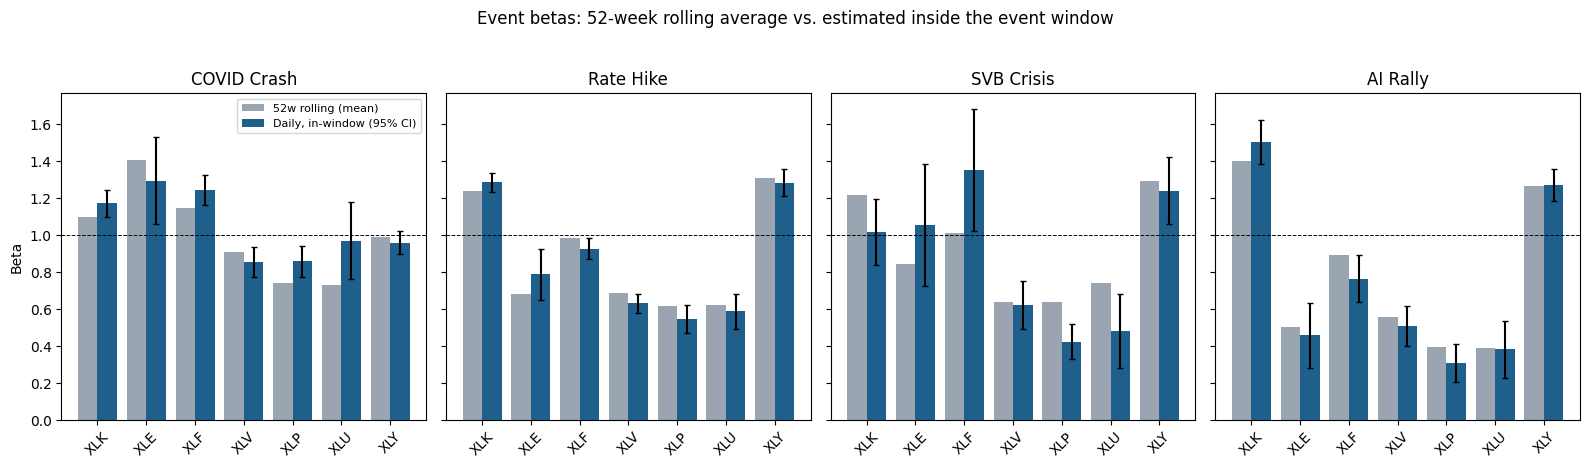

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)
for ax, e in zip(axes, REPORTED):
    sub = event_betas[event_betas.event == e].set_index("sector").loc[SECTORS]
    x = np.arange(len(SECTORS))
    ax.bar(x - 0.2, sub["rolling52_mean"], 0.4, label="52w rolling (mean)", color="#9aa5b1")
    ax.bar(x + 0.2, sub["beta_daily_in_window"], 0.4, yerr=1.96 * sub["se_hac"], capsize=2,
           label="Daily, in-window (95% CI)", color="#1f5f8b")
    ax.axhline(1, color="black", lw=0.7, ls="--")
    ax.set_xticks(x); ax.set_xticklabels(SECTORS, rotation=45); ax.set_title(e)
axes[0].set_ylabel("Beta"); axes[0].legend(fontsize=8)
plt.suptitle("Event betas: 52-week rolling average vs. estimated inside the event window", y=1.03)
plt.tight_layout(); plt.savefig("../figures/event_window_vs_rolling_beta.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Formal test for beta shifts

Full-sample daily regression per sector with an intercept and slope shift for each event: r_s = a + b r_m + sum_e (c_e D_e + d_e D_e r_m) + e. Events overlap in time (the SVB crisis sits inside the rate-hike cycle, the 2022 bear market overlaps the rate-hike start), so d_e is the *incremental* beta shift in that window. HAC(10) errors.

In [7]:
rows = []
for s in SECTORS:
    X = pd.DataFrame({"mkt": daily["excess_SPY"]})
    for _, r in events.iterrows():
        D = ((daily.index >= r.start_date) & (daily.index <= r.end_date)).astype(float)
        X[f"D_{r.event_name}"] = D
        X[f"Dxmkt_{r.event_name}"] = D * daily["excess_SPY"]
    res = sm.OLS(daily[f"excess_{s}"], sm.add_constant(X), missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": 10})
    for _, r in events.iterrows():
        k = f"Dxmkt_{r.event_name}"
        rows.append({"sector": s, "event": r.label, "base_beta": res.params["mkt"],
                     "beta_shift": res.params[k], "t_stat": res.tvalues[k], "p_value": res.pvalues[k]})
tests = pd.DataFrame(rows)
tests.round(4).to_csv("../outputs/beta_shift_tests.csv", index=False)
sig = tests.pivot(index="sector", columns="event", values="beta_shift").round(2).astype(str) + \
      tests.pivot(index="sector", columns="event", values="p_value").map(lambda p: "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else "")
sig[[EVENT_LABELS[e] for e in events.event_name]]

event,COVID Crash,COVID Recovery,2022 Bear Market,Rate Hike,SVB Crisis,AI Rally
sector,,,,,,
XLE,0.38***,0.56***,-0.42**,0.14,-0.01,-0.46***
XLF,0.25***,0.21***,-0.04,-0.06,0.42**,-0.23***
XLK,-0.16***,-0.19***,-0.05,-0.0,-0.31***,0.17**
XLP,0.33***,0.09**,-0.06,0.06,-0.16***,-0.22***
XLU,0.66***,0.61***,-0.09,0.34***,-0.17*,0.07
XLV,0.06,0.03,-0.0,-0.16***,-0.01,-0.28***
XLY,-0.13***,-0.1***,0.2***,0.07,0.08,0.18***


In [8]:
n_sig = (tests.p_value < 0.05).sum()
print(f"Beta shifts significant at 5%: {n_sig} of {len(tests)} sector-event pairs")
print(tests[tests.p_value < 0.05].sort_values("p_value")[["sector", "event", "beta_shift", "t_stat", "p_value"]].round(3).to_string(index=False))

Beta shifts significant at 5%: 25 of 42 sector-event pairs
sector            event  beta_shift  t_stat  p_value
   XLU      COVID Crash       0.662   8.022    0.000
   XLP      COVID Crash       0.327   7.948    0.000
   XLU        Rate Hike       0.343   5.028    0.000
   XLF      COVID Crash       0.250   4.993    0.000
   XLK      COVID Crash      -0.161  -4.723    0.000
   XLE         AI Rally      -0.458  -4.717    0.000
   XLU   COVID Recovery       0.614   4.703    0.000
   XLV         AI Rally      -0.284  -4.452    0.000
   XLE   COVID Recovery       0.563   4.288    0.000
   XLE      COVID Crash       0.377   4.010    0.000
   XLK   COVID Recovery      -0.192  -3.954    0.000
   XLY 2022 Bear Market       0.197   3.895    0.000
   XLY         AI Rally       0.179   3.763    0.000
   XLP         AI Rally      -0.224  -3.691    0.000
   XLY      COVID Crash      -0.132  -3.550    0.000
   XLK       SVB Crisis      -0.315  -3.548    0.000
   XLV        Rate Hike      -0.160  -3.

## 5. Findings

1. **The published 52-week table reproduces exactly** (max difference < 1e-15).
2. **For short events, the 52-week rolling mean is mostly pre-event data.** Only **5.8%** of the observations in the windows used for the COVID crash (5 weeks) and **8.7%** for the SVB crisis (8 weeks) fall inside the event. Even a 26-week window is only 12-17% "in-event". Long regimes (rate-hike cycle, AI rally) are 60%+ in-window, so those rolling numbers are representative.
3. **Measured inside the window, the short-event conclusions change.**
   - *COVID crash:* utilities (0.97) and staples (0.86) moved almost one-for-one with the market, well above their full-sample betas (0.64 / 0.60). The rolling table (0.73 / 0.74) understated this. Defensive sectors did **not** stay defensive in the crash.
   - *SVB crisis:* financials' beta jumped to **1.35** (rolling mean 1.01), which is the expected bank-stress signature, while technology fell to 1.02 (rolling 1.21).
   - *Long regimes* agree with the rolling results: in the AI rally XLK = 1.50, XLE = 0.46, XLU / XLP ≈ 0.3-0.4.
4. **Beta shifts are statistically significant.** In the interaction regression, 25 of 42 sector-event beta shifts are significant at 5% (HAC). The largest are utilities in the COVID crash (+0.66, t = 8.0) and during the rate-hike cycle (+0.34, t = 5.0), and energy in the AI rally (-0.46, t = -4.7).

**Takeaway:** use rolling betas to describe slow regime changes. For short, sharp events, estimate beta inside the event window (or use EWMA / Kalman-filter betas), and test shifts formally rather than comparing averages.